<a href="https://colab.research.google.com/github/Romani-cs/romani_INFO4670_Fall2026/blob/main/Wk3_NorthGate_Through_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [23]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [25]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [26]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

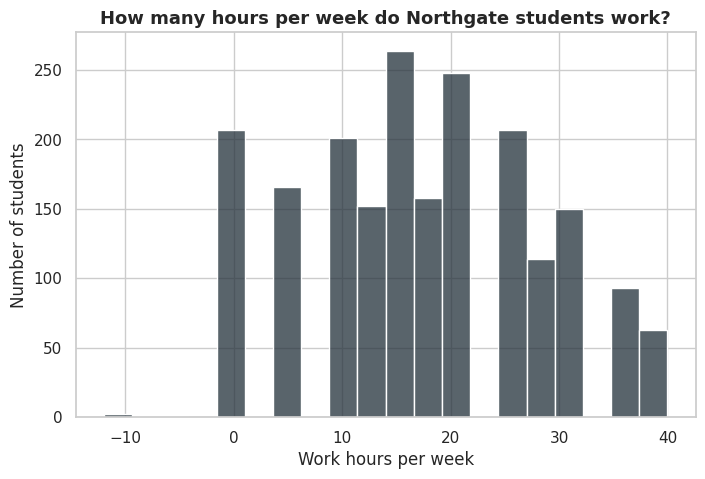

In [27]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", bins=20, color=NAVY, ax=ax)
ax.set_title("How many hours per week do Northgate students work?")
ax.set_xlabel("Work hours per week")
ax.set_ylabel("Number of students")
plt.show()


**STAR story — Q1** *(write in your own words)*

- **Scope —** A Histogram of work_hours_per_week for all 2,027 rows in student_records.csv.

- **Track —** How many hours per week do Northgate students work and how spread out is it?

- **Articulate —** The shape is unimodal with one clear peak between 14 and 20 hours per week then it drops off on both sides. The middle half of students work between 10 and 25 hours per week, with a median of 18. Additionally there appears to be some students with negative hours worked on the left side.

- **Respond —** Negative work hours aren't real values, so the rows containing them are probably a data entry error and should be fixed.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

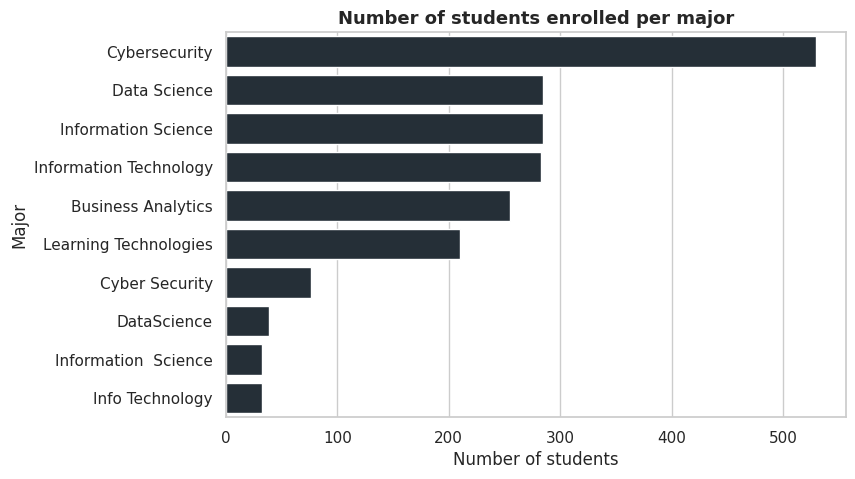

In [28]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

order = students["major"].value_counts().index
fig, ax = plt.subplots()
sns.countplot(data=students, y="major", order=order, color=NAVY, ax=ax)
ax.set_title("Number of students enrolled per major")
ax.set_xlabel("Number of students")
ax.set_ylabel("Major")
plt.show()


**STAR story — Q2** *(write in your own words)*

- **Scope —** A sorted bar chart of the major column for all 2,027 student records.

- **Track —** How does enrollment compare across majors?

- **Articulate —** Cybersecurity seems to be the largest program by far at 530 students. The chart also shows 10 bars but only 6 majors with the top 4 repeated twice.

- **Respond —** The Bar chart seems inconsistent because some of the data for the 4 repeated majors are separated. Merging them into their rightful positions will make the total different and accurately reflect the enrollment ranking.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

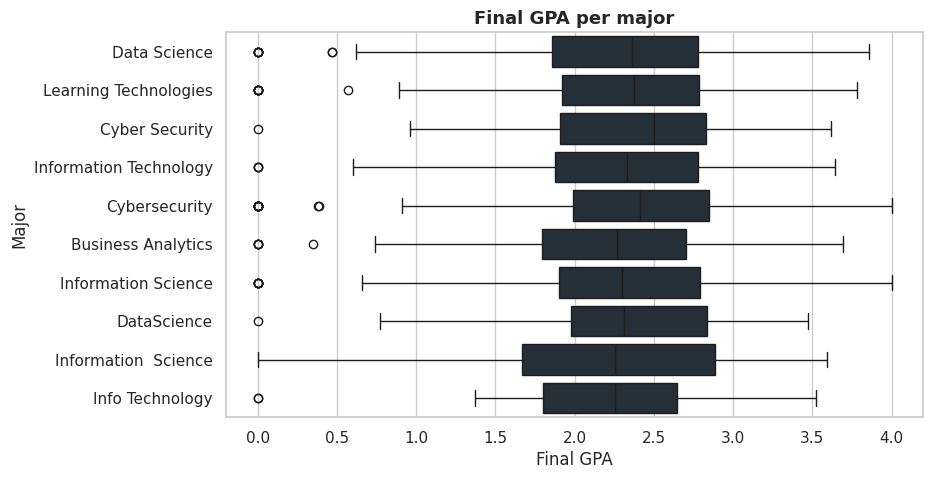

In [29]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()


fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=students, x="final_gpa", y="major", color=NAVY, ax=ax)
ax.set_title("Final GPA per major")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")
plt.show()

**STAR story — Q3** *(write in your own words)*

- **Scope —** A box plot of final_gpa split by major.

- **Track —** Does final GPA differ across majors?

- **Articulate —** ~2.2 and 2.5. However, every single major shares the problem where a cluster of students have a 0.0 GPA.

- **Respond —** Since the 0.00 GPAs appear across all majors almost identically, it seems like a system error or placeholder and not an actual failure of a student.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

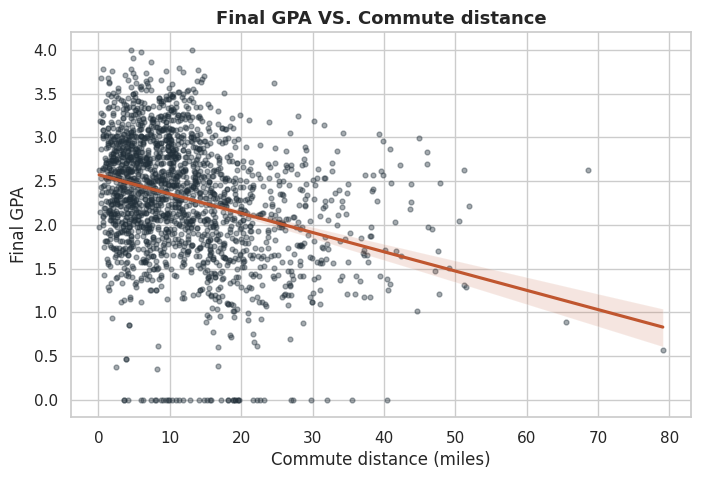

In [30]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()


fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Final GPA VS. Commute distance")
ax.set_xlabel("Commute distance (miles)")
ax.set_ylabel("Final GPA")
plt.show()


**STAR story — Q4** *(write in your own words)*

- **Scope —** A scatterplot with a trend line which shows commute_miles vs final_gpa, one dot per student.

- **Track —** Is there a relationship between commute distance and final GPA?

- **Articulate —** Longer commutes are slightly linked to lower GPAs, but commute distance definitely doesn't tell the entire story.

- **Respond —** A correlation doesn't mean the commute is the actual cause of the lower GPA. There could be separate additional factors that contribute to this that you would have to take into account before making the seeing if commuting is the standalone issue.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

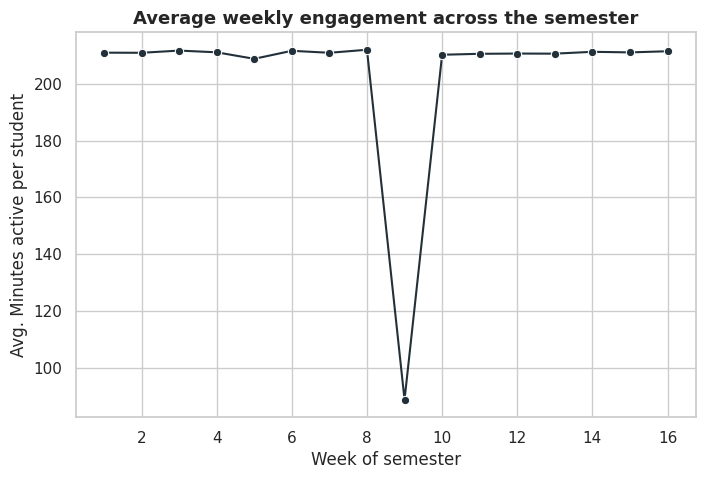

In [31]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active",
             color=NAVY, marker="o", ax=ax)
ax.set_title("Average weekly engagement across the semester")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Avg. Minutes active per student")
plt.show()


**STAR story — Q5** *(write in your own words)*

- **Scope —** A line chart of minutes_active from weekly_activity.csv, averaged across all students for each week.

- **Track —** How does student engagement change across the semester?\

- **Articulate —** Student engagement is completely steady across the semester, except for a single huge drop during week 9.

- **Respond —** The week 9 drop seems to be real, planned break and not the result of a data error or students quitting.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Do students who eventually drop out report different study hours than students who stay enrolled?



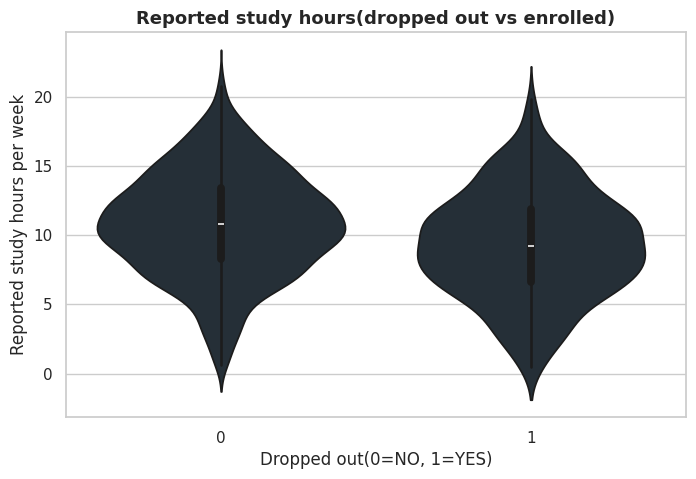

In [32]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

fig, ax = plt.subplots()
sns.violinplot(data=students, x="dropped_out", y="study_hours_reported", color=NAVY, ax=ax)
ax.set_title("Reported study hours(dropped out vs enrolled)")
ax.set_xlabel("Dropped out(0=NO, 1=YES)")
ax.set_ylabel("Reported study hours per week")
plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** A violin plot of study_hours_reported split by dropped_out, from students who reported a value.

- **Track —** Do students who eventually drop out report different study hours than students who stay enrolled?

- **Articulate —** Students who dropped out spent slightly less time on the system, but the two groups still look very similar overall.

- **Respond —** Because the two groups overlap so much, study hours alone wouldn't be a reliable way to predict who drops out.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.